# Imports

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')


# Merge Datasets

In [59]:
X_train = pd.read_csv('X_train_data_HAR.txt', delim_whitespace=True, header=None)
print(f'Shape Of X_train:-{X_train.shape}')

X_test=pd.read_csv('X_test_data_HAR.txt',delim_whitespace=True,header=None)
print(f'Shape Of X_test:-{X_test.shape}')

y_train = pd.read_csv('y_train_data_HAR.txt',delim_whitespace=True,header=None)
print(f'Shape Of y_train:-{y_train.shape}')

y_test = pd.read_csv('y_test_data_HAR.txt',delim_whitespace=True,header=None)
print(f'Shape Of y_test:-{y_test.shape}')


Shape Of X_train:-(7352, 561)
Shape Of X_test:-(2947, 561)
Shape Of y_train:-(7352, 1)
Shape Of y_test:-(2947, 1)


In [60]:
X = pd.concat([X_train,X_test],axis=0)
y = pd.concat([y_train,y_test],axis=0)

print(f'Shape Of X:-{X.shape}')
print(f'Shape Of y:-{y.shape}')

df = X.copy()
df['target'] = y.values
print(f'Shape Of df:-{df.shape}')
df.sample(5)

Shape Of X:-(10299, 561)
Shape Of y:-(10299, 1)
Shape Of df:-(10299, 562)


,0,1,2,3,4,5,6,7,8,9,...,552,553,554,555,556,557,558,559,560,target
5653,0.266437,-0.037025,-0.124737,-0.175511,-0.162286,-0.470721,-0.305530,-0.195501,-0.476060,0.068685,...,0.020627,-0.412524,0.005347,0.917930,0.953562,-0.072594,-0.787926,0.244392,0.027871,2
1731,0.278337,-0.020052,-0.111465,-0.995799,-0.986174,-0.993490,-0.995878,-0.984867,-0.992993,-0.939064,...,-0.727701,-0.944265,0.190481,0.156571,-0.513223,-0.475003,-0.610918,-0.159205,-0.070786,4
293,0.223269,-0.000141,-0.159088,-0.244329,0.178954,-0.264743,-0.316683,0.168558,-0.331238,0.171684,...,-0.149155,-0.563593,0.460829,0.310394,0.892758,0.843190,-0.535812,0.418332,0.001905,2
1754,0.162781,-0.031743,-0.146423,-0.158353,0.498697,0.005215,-0.208448,0.355419,0.025925,0.146770,...,-0.692278,-0.951207,0.538271,0.443406,-0.495401,-0.247945,-0.689131,0.312044,-0.001719,2
1726,0.278086,-0.014304,-0.112497,-0.996106,-0.982456,-0.993058,-0.996310,-0.981837,-0.994811,-0.942102,...,-0.544161,-0.816487,-0.139608,0.355073,-0.269276,0.439541,-0.608850,-0.160218,-0.072166,4


# Understad Data

In [61]:
# Info of Data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10299 entries, 0 to 2946
Columns: 562 entries, 0 to target
dtypes: float64(561), int64(1)
memory usage: 44.2 MB


In [62]:
# Duplicated Record Check
df.duplicated().sum()

np.int64(0)

In [63]:
# Check NAN Or missing Data
df.isna().sum()[(df.isna().sum()) > 0]

,0


In [64]:
# Top 10 Features With High Varience
df.drop(columns='target').var().sort_values(ascending=False).head(10)

,0
366,0.561720
367,0.539207
234,0.524056
287,0.522666
78,0.495532
79,0.491624
56,0.485049
77,0.484871
260,0.479467
510,0.459960


# Exploratory Data Analysis

In [65]:
# Target Feature Distribution
df.target.value_counts(normalize=True)*100


,proportion
target,
6,18.875619
5,18.506651
4,17.254102
1,16.720070
2,14.991747
3,13.651811


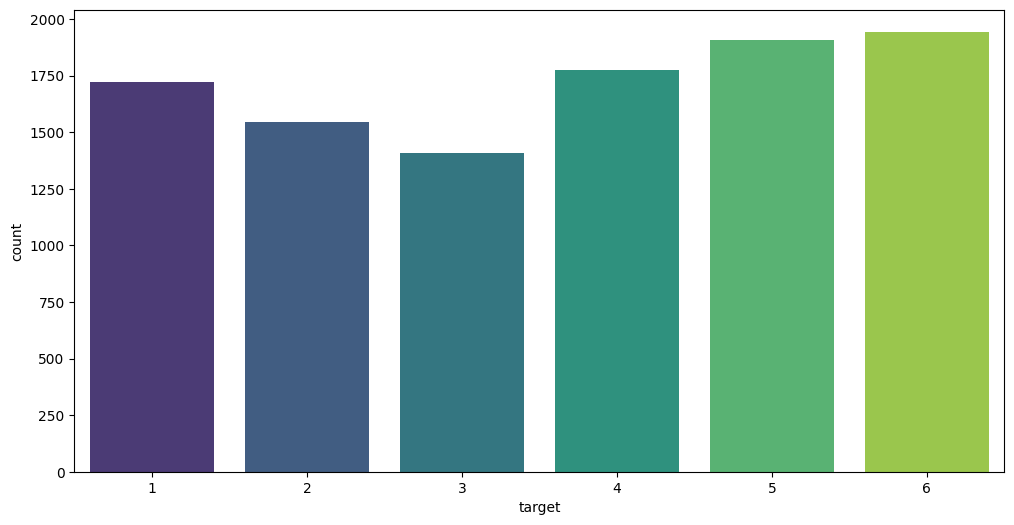

In [66]:
# Plot of Target Distribution
plt.figure(figsize=(12,6))
sns.countplot(x=df.target,palette='viridis')
plt.show()

# Slightly Imbalance But OK At this level

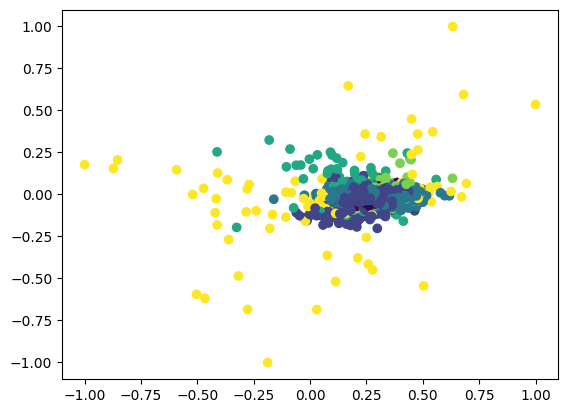

In [67]:
# Class Seperation Check:-
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=df['target'])
plt.show()

## Two individual features are not sufficient to separate the classes.

# Principal-Component-Analysis (PCA)

In [68]:
# Checking For Mean Centered Data:-
df.iloc[:, :-1].mean().head(10)
# Data is not mean-centered: Scaling Needed

,0
0,0.274347
1,-0.017743
2,-0.108925
3,-0.607784
4,-0.510191
5,-0.613064
6,-0.633593
7,-0.525697
8,-0.614989
9,-0.466732


In [69]:
# Scaling Data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.iloc[:,:-1])

pd.DataFrame(X_scaled).mean().sample(5)
# Now Features Are MEan Centered

,0
48,5.077769e-16
301,8.692920e-17
132,1.021073e-16
551,1.034871e-17
43,7.313092e-16


In [70]:
# Create Pca Object:-

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

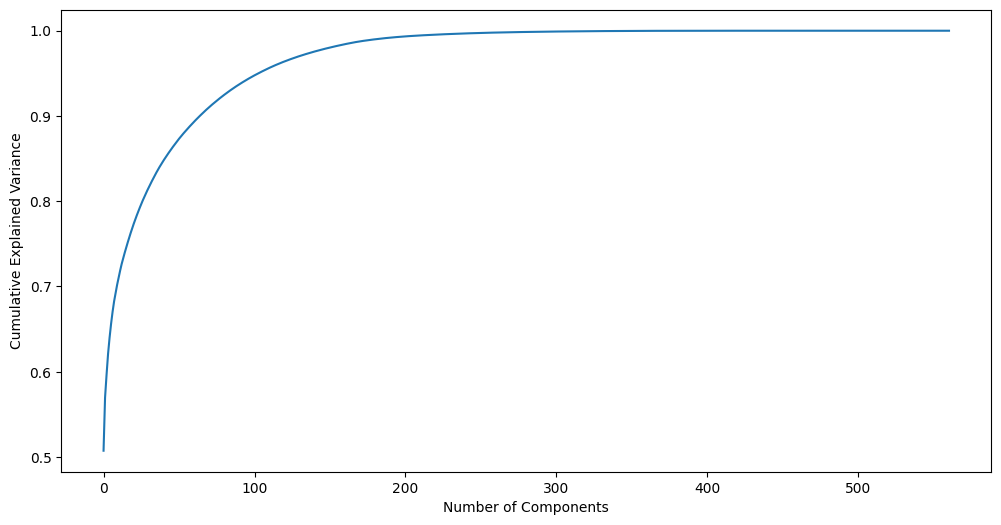

In [71]:
# Explained varience:-
explained_varience = np.cumsum(pca.explained_variance_ratio_)

# Scree Plot To Find Out Optimal Principal Components:
plt.figure(figsize=(12,6))
plt.plot(explained_varience)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()


In [72]:
# Apply PCA With Choosen Component:-
pca = PCA(n_components=125)
X_pca_final = pca.fit_transform(X_scaled)
print(f'Shape Of X_pca_final:-{X_pca_final.shape}')

Shape Of X_pca_final:-(10299, 125)


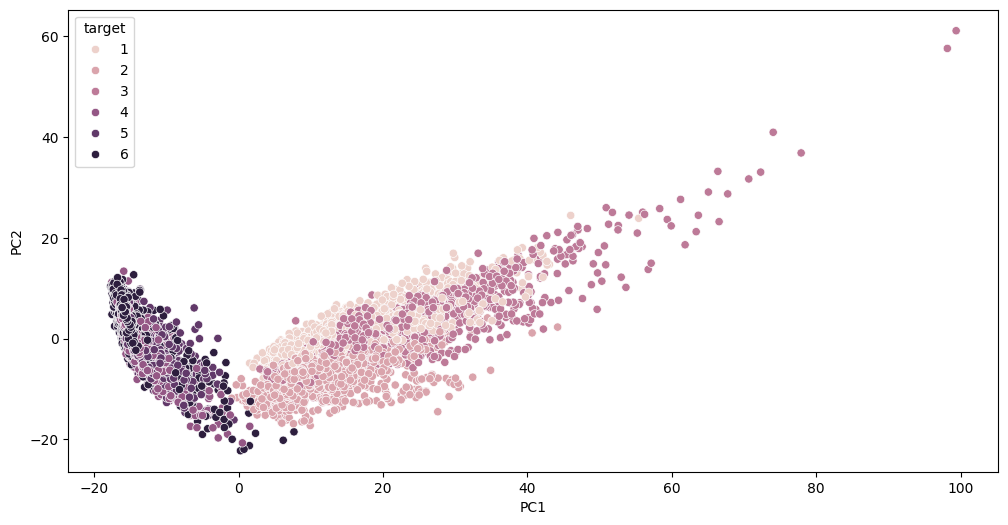

In [73]:
# 2-D Plot PCA

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(12,6))
sns.scatterplot(x=X_pca_2[:,0],y=X_pca_2[:,1],hue=df.target)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### Initial visualization using raw features showed no clear separation. After applying PCA, the data revealed underlying structure with partial class separation, indicating that PCA successfully captured important variance in the data

# Model-1:- Without-PCA

In [74]:
# Logistic Regression Without PCA:-

X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)

model1 = LogisticRegression(max_iter=1000)

model1.fit(X_train,y_train)

y_pred = model1.predict(X_test)

print(f'Accuracy Score Without-PCA:-{accuracy_score(y_test,y_pred)}')

Accuracy Score Without-PCA:-0.9825242718446602


# Model-2:- With PCA

In [75]:
# Logistic Regression With PCA (125 PCA Features):-

X_train_pca,X_test_pca,y_train_pca,y_test_pca = train_test_split(X_pca_final,y,test_size=0.2,random_state=42)

model2 = LogisticRegression(max_iter=1000)

model2.fit(X_train_pca,y_train_pca)

y_pred_pca = model2.predict(X_test_pca)

print(f'Accuracy Score With PCA:-{accuracy_score(y_test_pca,y_pred_pca)}')

Accuracy Score With PCA:-0.9728155339805825


# Conclusion:-

### Applying PCA reduced the feature space from `561 to 125` dimensions while retaining comparable model performance `only ~1% drop in accuracy`, significantly improving computational efficiency.

### PCA proved to be a powerful technique for balancing model efficiency and performance, making it highly valuable for real-world high-dimensional datasets where scalability and speed are critical.